# S3a_SnowModel_JDSSS_scenarios.ipynb
This notebook compares the SnowModel point scenarios at JDSSS

For additional details see ../postprocess/output_comp.ipynb


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Functions

In [2]:
def slice_and_match(df_cues_model,yr_start,yr_end,var_obs,var_sm,ds_model):
    # clean observed table
    df_obs_slice = df_cues_model[(df_cues_model['DateTime'] >= np.datetime64(f'{yr_start}-10-01')) & (df_cues_model['DateTime'] <= np.datetime64(f'{yr_end}-07-01'))]
    df_obs_var = df_obs_slice[['DateTime',var_obs]]
    df_obs_var = df_obs_var.set_index('DateTime')
    df_obs_var = df_obs_var.iloc[1:]

    # resample
    df_observed = df_obs_var.resample(
        "3H",
        # offset="1H",
        label="right",
        closed="right"
    ).mean()
    # rename
    df_observed = df_observed.rename(columns = {var_obs: 'Obs'})
    # model
    ds_model_slice = ds_model.where(ds_model.time.isin(df_obs_slice.DateTime.values),drop = True)
    # match timesteps
    df_model = ds_model_slice[var_sm][1:,0,0].to_dataframe().drop(columns = ['xlat','xlon'])
    # rename
    df_model = df_model.rename(columns = {var_sm: 'CONUS404'})
    return df_observed, df_model

def five_yr_plot_comp(sm_output_dir,var_sm,var_obs,df_cues_model,yr_start,yr_end,title):
    ds = xr.load_dataset(f'{sm_output_dir}{var_sm}.nc')

    fig,ax = plt.subplots(5,1,figsize = (12,10))
    count = 0
    biases = []
    for yr in range(yr_start,yr_end):
    
        resampled,df_model = slice_and_match(df_cues_model,yr-1,yr,var_obs,var_sm,ds)
    
        resampled.plot(ax=ax[count],label = None)
        df_model.plot(ax=ax[count],color = 'orange',label = None)
        ax[count].legend()

        merge_df = pd.merge(left = resampled,right = df_model,how = 'inner',left_index = True,right_index = True)
        avg_obs = merge_df['Obs'].mean()
        avg_mod = merge_df['CONUS404'].mean()
        bias2 = avg_mod - avg_obs
        print('bias2',bias2)
        year_bias = np.sum(merge_df.Obs - merge_df.CONUS404) / len(merge_df.Obs)
        ax[count].set_title(f'{yr}: {year_bias:.2f} bias',fontweight = 'bold')
        count += 1
        biases.append(year_bias)

    plt.suptitle(title,fontweight = 'bold')
    plt.tight_layout()
    plt.show()
    return np.array(biases)

# Load Data

## JDSSS Observations

In [3]:
obs_dir = '../../data/cues/cues/'
# CUES all QA/QC'd data.
df_obs1 = pd.read_csv(f'{obs_dir}cues2011to2017_Radiation_Albedo_WindSpeed_GroundTemp_AirTemp_RH_AirPressure_SnowDepth_SWE.csv')
df_obs1['DateTime'] = pd.to_datetime(df_obs1['DateTime'])
# CUES all SWE
df_swe = pd.read_csv(f'{obs_dir}cues_swe_merge_hourly_v1.csv')
df_swe['DateTime'] = pd.to_datetime(df_swe['DateTime'])

/glade/derecho/scratch/rossamower/tmp/ipykernel_109142/94123105.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_obs1['DateTime'] = pd.to_datetime(df_obs1['DateTime'])


## SnowModel Scenarios

### SM Baseline

In [4]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/wy_2013-2022/netcdf/'
var = 'swed'
sm_baseline_ds = xr.load_dataset(f'{sm_output_dir}{var}.nc')

### SM prec-adj

In [5]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/corrected/wy_2013-2022/netcdf/'
var = 'swed'
sm_prec_adj_ds = xr.load_dataset(f'{sm_output_dir}{var}.nc')

### SM Optimized

In [6]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/optimized/wy_2013-2022/netcdf/'
var = 'swed'
sm_optimized_ds = xr.load_dataset(f'{sm_output_dir}{var}.nc')

# Scenario SWE Comparison

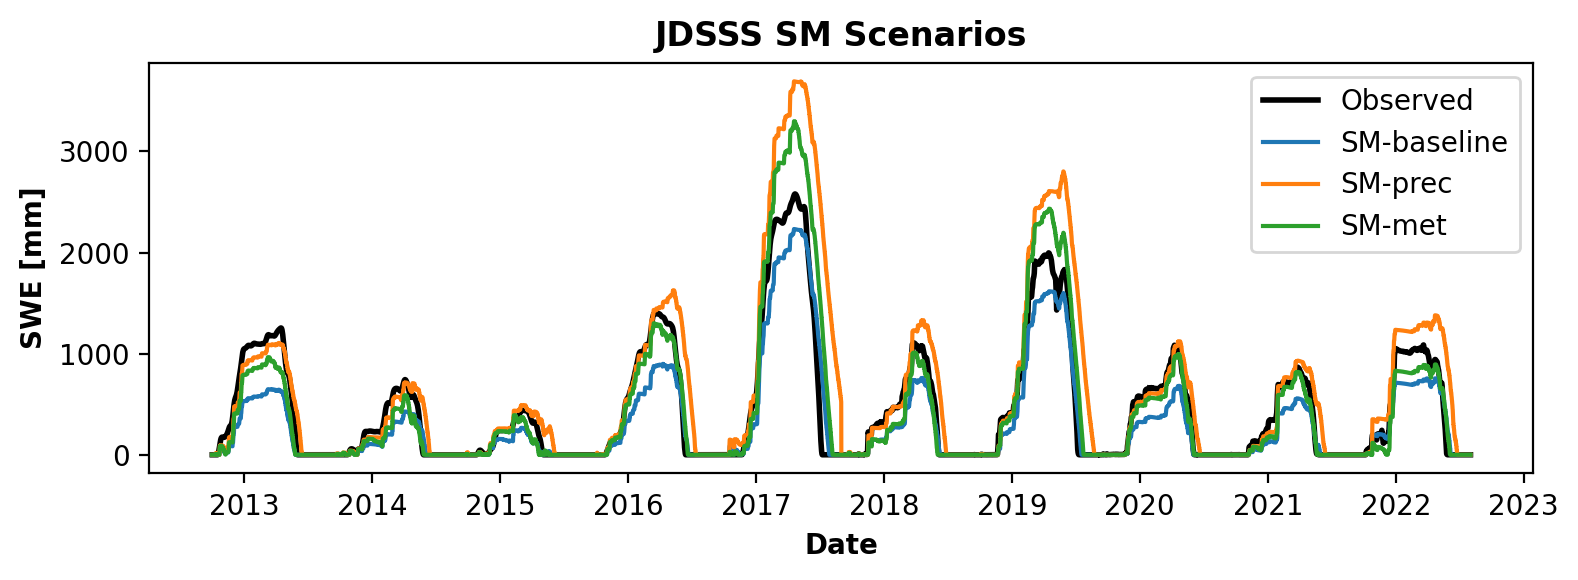

In [8]:
# slice observations
df_cues_model = df_swe[(df_swe['DateTime'] >= sm_baseline_ds.time[0].values) & (df_swe['DateTime'] <= sm_baseline_ds.time[-1].values)]


fig,ax = plt.subplots(figsize = (8,3),dpi = 200)
ax.plot(df_cues_model['DateTime'],df_cues_model['SWE_cm']*10,label = 'Observed',color = 'black',linewidth = 2)
(sm_baseline_ds[var][:,0,0]*1000).plot(ax=ax,color = 'C0',label = 'SM-baseline')
(sm_prec_adj_ds[var][:,0,0]*1000).plot(ax=ax,color = 'C1',label = 'SM-prec')
(sm_optimized_ds[var][:,0,0]*1000).plot(ax=ax,color = 'C2',label = 'SM-met')

plt.ylabel('SWE [mm]',fontweight = 'bold')
plt.xlabel('Date',fontweight = 'bold')
plt.title('JDSSS SM Scenarios',fontweight = 'bold')
plt.legend()
plt.tight_layout()
plt.savefig('./pngs/S5_JDSSS_SM_Scenarios.png',dpi=300)

# Bias Derivation

## precipitation

In [8]:
agg_all = []
agg_early = []
for wy in range(2013,2018):
    obs_swe_slice = df_swe[(df_swe['DateTime'] >= np.datetime64(f'{wy-1}-10-01')) & (df_swe['DateTime'] < np.datetime64(f'{wy}-10-01'))]
    peak_swe = obs_swe_slice['SWE_cm'].max()
    peak_date = obs_swe_slice[obs_swe_slice['SWE_cm'] == peak_swe]['DateTime'].values
    peak_swe *= 10
    sm_peak = sm_baseline_ds.where(sm_baseline_ds.time == peak_date,drop = True).swed[0,0,0].values*1000
    if wy != 2017:
        agg_early.append(peak_swe/sm_peak)
    agg_all.append(peak_swe/sm_peak)
    print(f'{wy}, obs peak {peak_swe}, date {str(peak_date[0])[0:10]}; SM-baseline {sm_peak}')
    print(f'RATIO = {peak_swe/sm_peak}\n')



2013, obs peak 1254.0000000000002, date 2013-04-16; SM-baseline 623.5743165016174
RATIO = 2.010987250140774

2014, obs peak 743.4166666666667, date 2014-04-05; SM-baseline 425.85495114326477
RATIO = 1.7457039413792534

2015, obs peak 440.0, date 2015-03-06; SM-baseline 266.17923378944397
RATIO = 1.6530215138723168

2016, obs peak 1399.3333333333335, date 2016-03-17; SM-baseline 876.8436908721924
RATIO = 1.5958754654908027

2017, obs peak 2579.5, date 2017-04-22; SM-baseline 2231.342315673828
RATIO = 1.1560306017954194



In [9]:
np.array(agg_early).mean()

1.7513970427207868

In [10]:
np.array(agg_all).mean()

1.6323237545357134

(15434.53125, 17419.0)

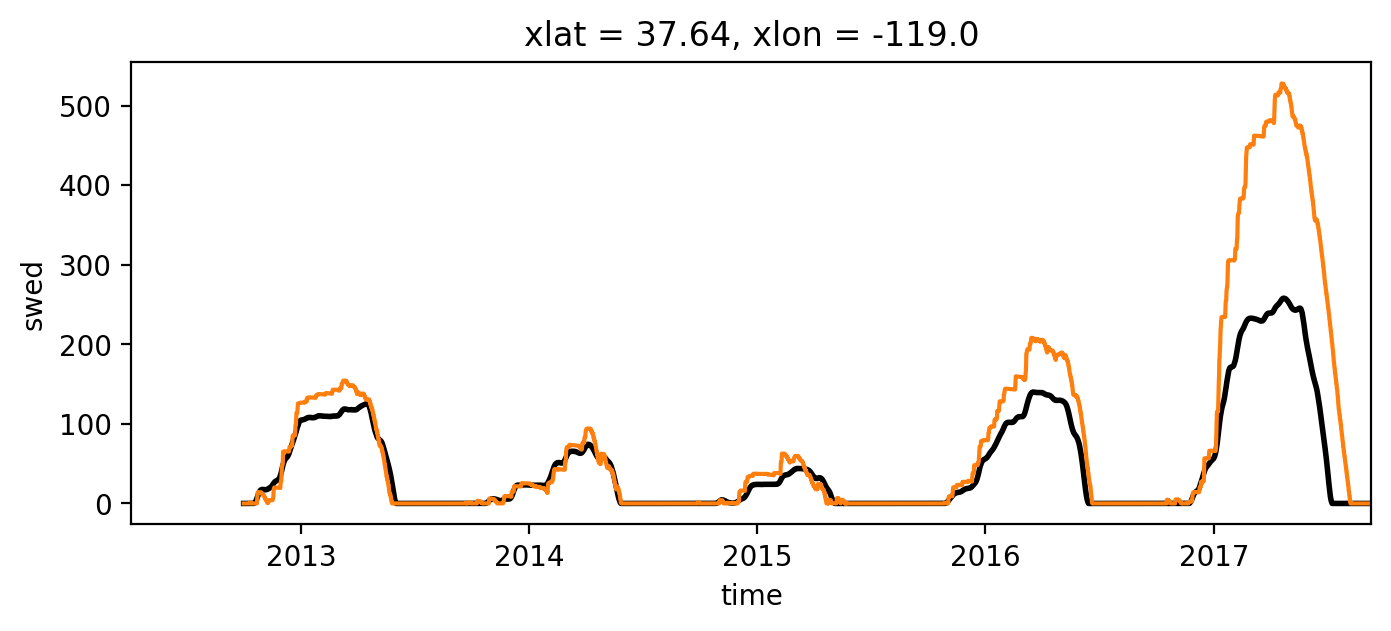

In [11]:
multiplier = 1.6
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/optimized/wy_2013-2022/netcdf/'
var = 'swed'
ds1 = xr.load_dataset(f'{sm_output_dir}{var}.nc')

df_cues_model = df_obs1[(df_obs1['DateTime'] >= ds1.time[0].values) & (df_obs1['DateTime'] <= ds1.time[-1].values)]

fig,ax = plt.subplots(figsize = (8,3),dpi = 200)
ax.plot(df_cues_model['DateTime'],df_cues_model['SWE_cm'],label = 'Cues Pillow',color = 'black',linewidth = 2)
(ds1[var][:,0,0] * 100 * multiplier).plot(ax=ax,color = 'C1',label = 'Sim w/ CONUS404 + EMP RAD')
plt.xlim(None,df_cues_model['DateTime'].max())

## air temperature

/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(


bias2 -1.8942290727319306
bias2 -1.9247635647199672
bias2 -1.730348000712738


/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(


bias2 -3.063736989927408
bias2 -3.698208203333201


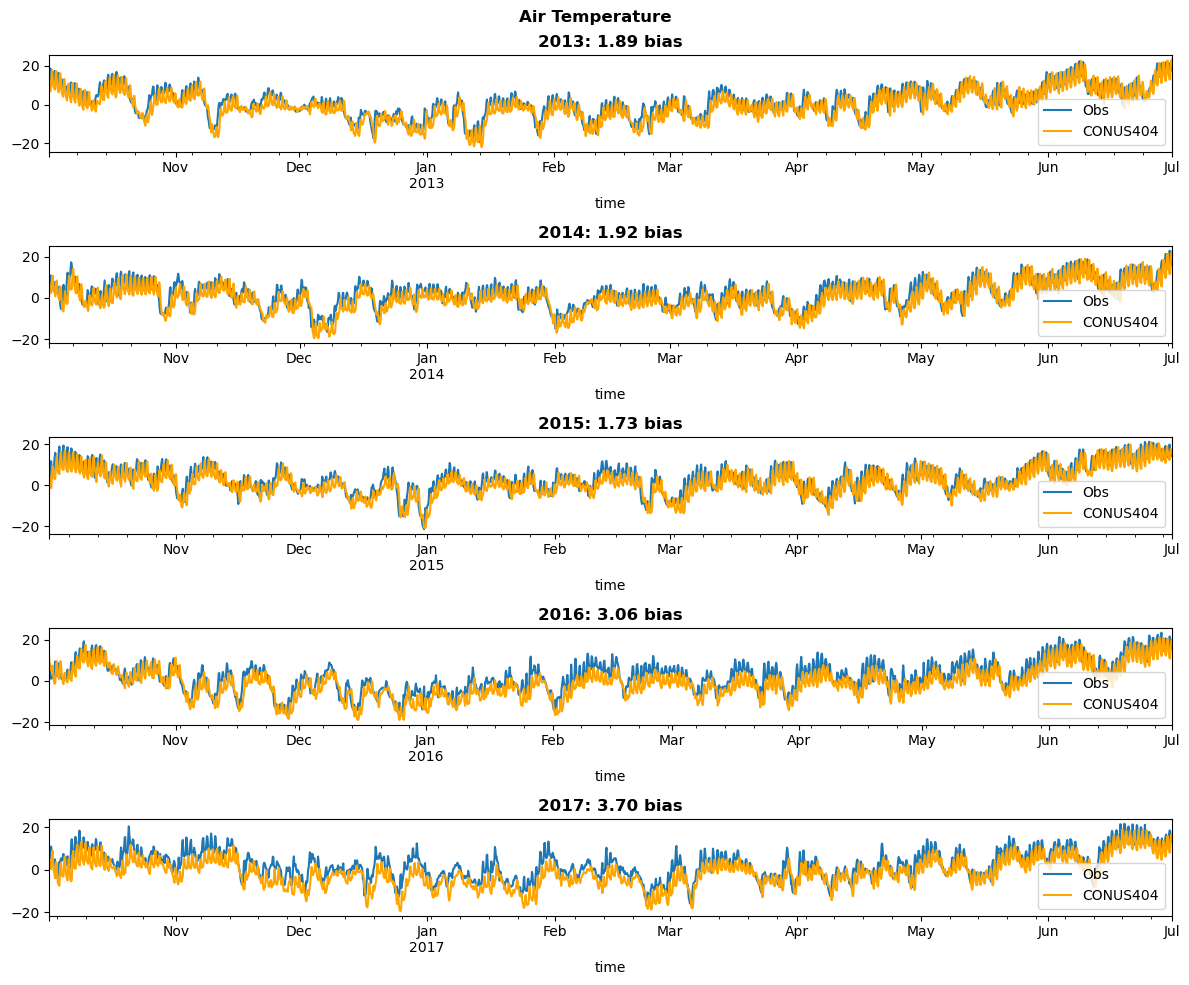

Average bias: 2.46


In [12]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/wy_2013-2022/netcdf/'
var_sm = 'tair'
var_obs = 'AirTemp_C'
yr_start,yr_end = 2013,2018
title = 'Air Temperature'
t_bias = five_yr_plot_comp(sm_output_dir,var_sm,var_obs,df_cues_model,yr_start,yr_end,title)
print(f'Average bias: {np.mean(t_bias):.2f}')

## albedo

bias2 -0.11507228943978276
bias2 -0.1504705703354181


/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(


bias2 -0.17541446622357748
bias2 -0.08517094765479061


/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(


bias2 -0.10681461405895021


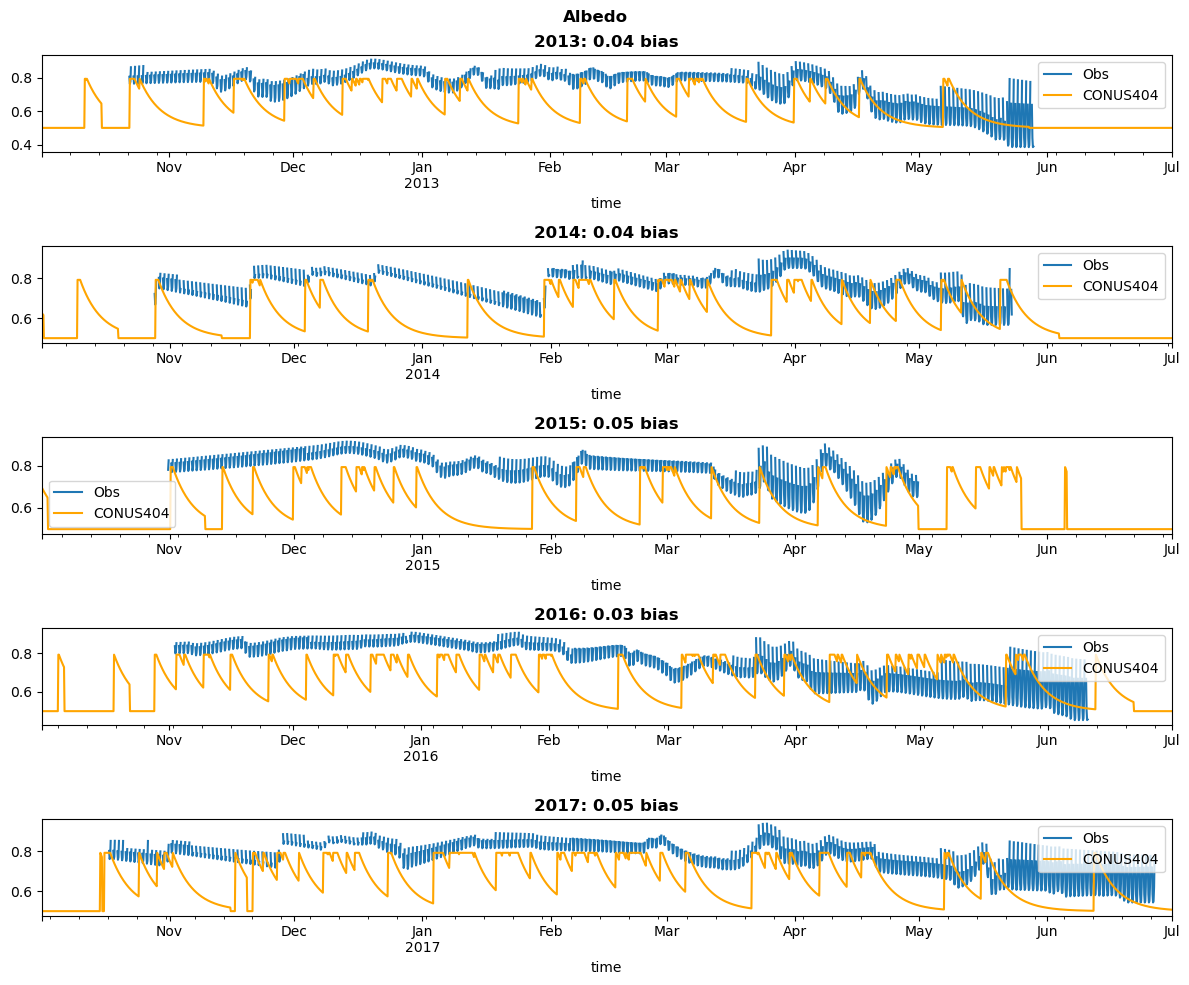

Average bias: 0.04


In [13]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/wy_2013-2022/netcdf/'
var_sm = 'albd'
var_obs = 'direct_broadband_snow_albedo'
yr_start,yr_end = 2013,2018
title = 'Albedo'
t_bias = five_yr_plot_comp(sm_output_dir,var_sm,var_obs,df_cues_model,yr_start,yr_end,title)
print(f'Average bias: {np.mean(t_bias):.2f}')

## incoming shortwave

bias2 -21.767219479383613
bias2 -9.502617450569687


/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(


bias2 -12.957108978532347
bias2 -6.121347877521032
bias2 -6.476844331138153


/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(


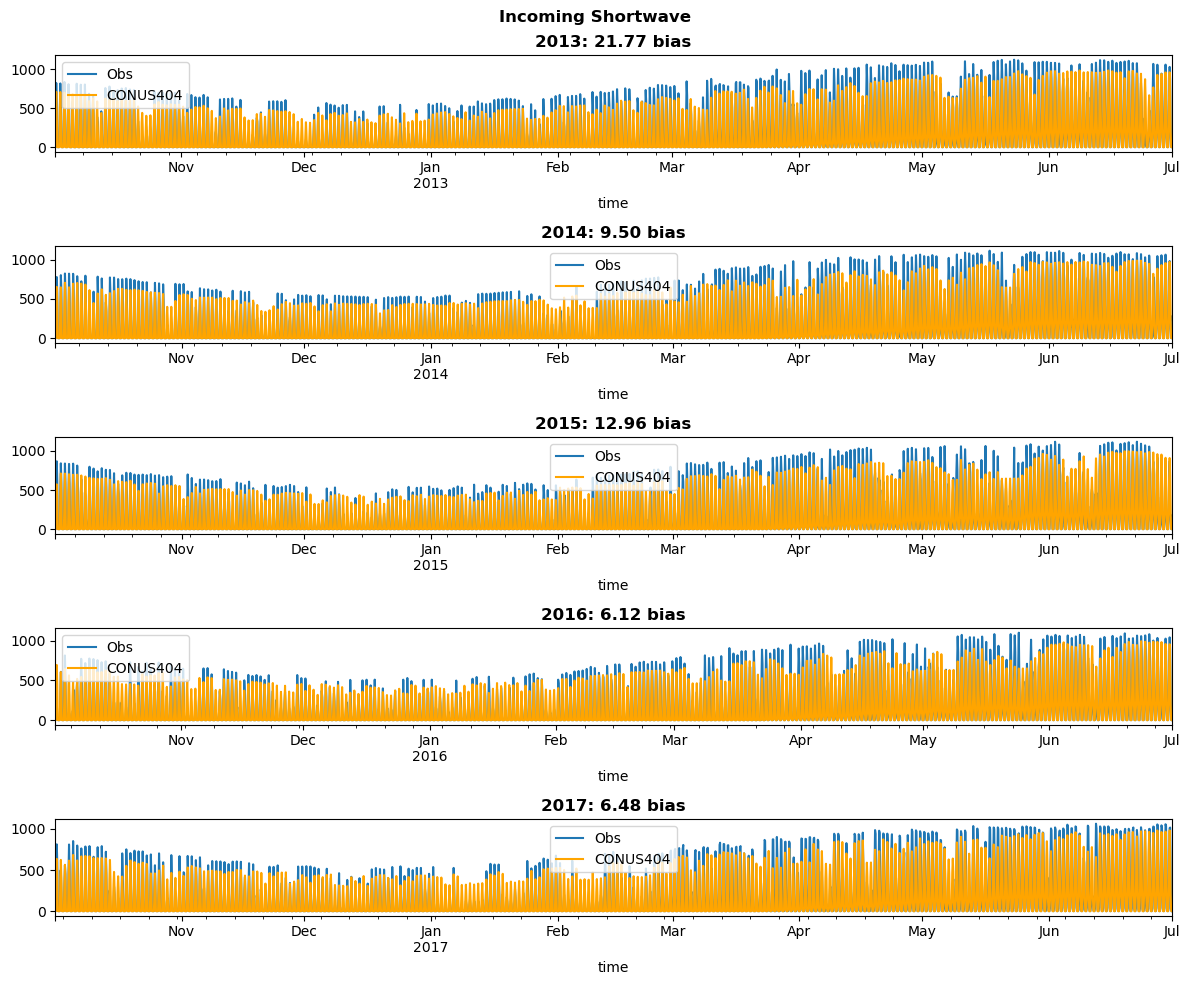

Average bias: 11.37


In [14]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/wy_2013-2022/netcdf/'
var_sm = 'qsin'
var_obs = 'uplooking_broadband_watts_per_meterxx2'
yr_start,yr_end = 2013,2018
title = 'Incoming Shortwave'
t_bias = five_yr_plot_comp(sm_output_dir,var_sm,var_obs,df_cues_model,yr_start,yr_end,title)
print(f'Average bias: {np.mean(t_bias):.2f}')

## incoming longwave

/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_observed = df_obs_var.resample(
/glade/derecho/scratch/rossamower/tmp/ipykernel_100617/3772666560.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  

bias2 -10.788790602777937
bias2 -12.244142022325008
bias2 -9.988079942044152
bias2 -13.192865747604941
bias2 -4.817590697198824


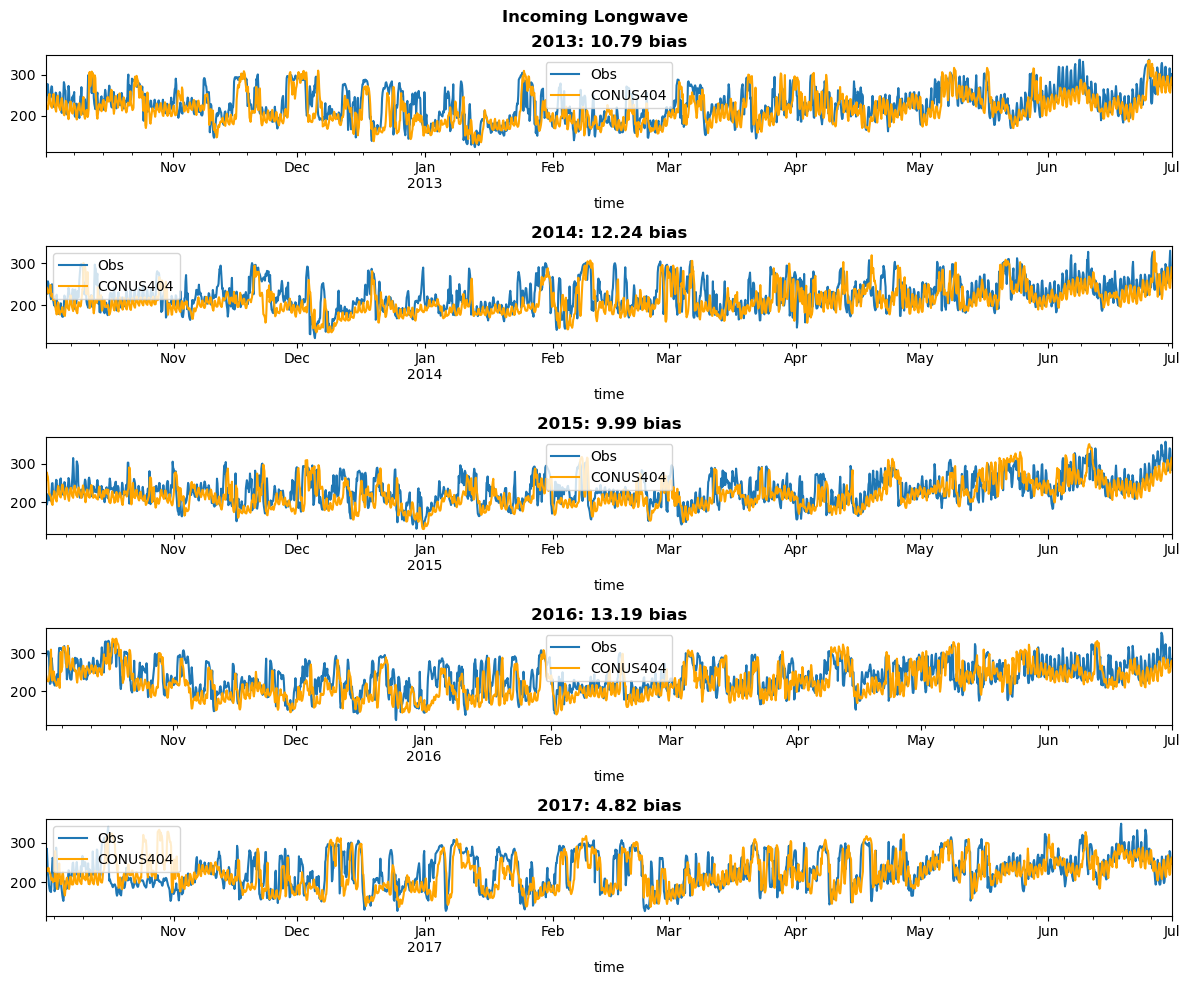

Average bias: 10.21


In [15]:
sm_output_dir = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/wy_2013-2022/netcdf/'
var_sm = 'qlin'
var_obs = 'uplooking_longwave_watts_per_meterxx2'
yr_start,yr_end = 2013,2018
title = 'Incoming Longwave'
t_bias = five_yr_plot_comp(sm_output_dir,var_sm,var_obs,df_cues_model,yr_start,yr_end,title)
print(f'Average bias: {np.mean(t_bias):.2f}')

# Appendix